In [1]:
import pyart
import matplotlib.pyplot as plt
import numpy as np
#import cartopy.crs as ccrs
import math
import warnings
from IPython import display
warnings.simplefilter("ignore")


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



MissingOptionalDependency: Basemap is required to use RadarMapDisplayBasemap but is not installed

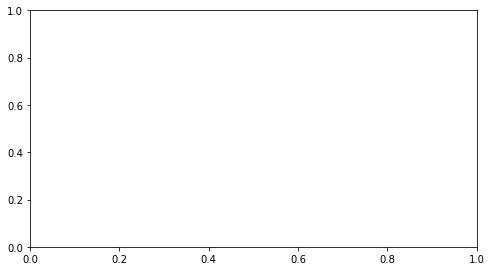

In [2]:
plt.figure(figsize=[8,20])

################################################################
#TIME=1
################################################################

radar = pyart.aux_io.read_odim_h5("/g/data/eg3/ab4502/radar/95_20201206_134034.pvol.h5", file_field_names=True)

clon=142.1962; clat=-36.7189; rlon=radar.longitude["data"][0]; rlat=radar.latitude["data"][0]
xlon=143.6; xlat=-37.92

ax=plt.subplot(4,1,1)
disp=pyart.graph.RadarMapDisplayBasemap(radar)
disp.plot_ppi_map("DBZH",13,cmap=pyart.graph.cm_colorblind.HomeyerRainbow, resolution="h",colorbar_label="DBHZ",\
        projection="aeqd",vmin=-10, vmax=70,ax=ax)
disp.basemap.plot([clon],[clat], marker="o", ms=10, mew=1, ls="-", color="k", latlon=True, mfc="none")

ax=plt.subplot(4,1,2)
disp=pyart.graph.RadarMapDisplayBasemap(radar)
disp.plot_ppi_map("VRADH",13,cmap=pyart.graph.cm_colorblind.HomeyerRainbow, resolution="h",\
        projection="aeqd",ax=ax)
disp.basemap.plot([clon],[clat], marker="o", ms=10, mew=1, ls="-", color="k", latlon=True, mfc="none")

#https://www.omnicalculator.com/other/azimuth
plt.subplot(4,1,3)
disp.plot_azimuth_to_rhi("DBZH",168.52,vmin=-10, vmax=70, cmap=pyart.graph.cm_colorblind.HomeyerRainbow,colorbar_label="DBHZ")
plt.ylim([0,14])
plt.xlim([-200,0])
plt.axvline(-81.85, linestyle="--", color="k")
plt.plot(-81.85, 0.5, marker="x", color="k", ms=10, mew=2)
#plt.title(disp.generate_az_rhi_title("DBZH",265.37).replace(" CLEAN",""))

plt.subplot(4,1,4)
disp.plot_azimuth_to_rhi("VRADH",168.52)
plt.ylim([0,14])
plt.xlim([-200,0])
plt.axvline(-81.85, linestyle="--", color="k")
plt.plot(-81.85, 0.5, marker="x", color="k", ms=10, mew=2)

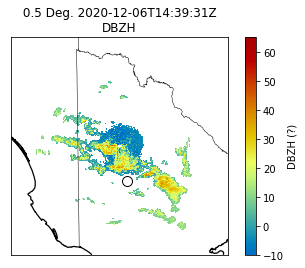

KeyboardInterrupt: 

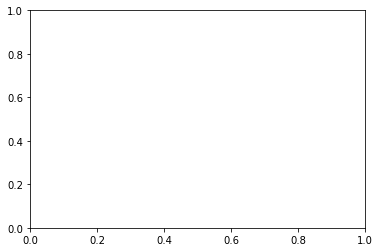

In [20]:
%matplotlib inline
import time
import pylab as pl
from IPython import display
import glob

step=5
for f in np.sort(glob.glob("/g/data/eg3/ab4502/radar/95_202012*"))[150::step]:

    radar = pyart.aux_io.read_odim_h5(f, file_field_names=True)

    plt.figure()
    
    disp=pyart.graph.RadarMapDisplayBasemap(radar)
    c=disp.plot_ppi_map("DBZH",13,cmap=pyart.graph.cm_colorblind.HomeyerRainbow)
    #plt.contourf(radar.fields['DBZH']['data'][radar.get_slice(1)]); plt.colorbar()
    disp.basemap.plot([142.1962],[-36.7189], marker="o", ms=10, mew=1, ls="-", color="k", latlon=True, mfc="none")
    
    display.clear_output(wait=True)
    display.display(pl.gcf())
    #time.sleep(0.1)    
    
    plt.close()
